In [1]:
import os
import joblib
import warnings
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
from sklearn.tree import plot_tree

In [2]:
model = joblib.load("../models/final_model.pkl")

preprocessor = joblib.load("../models/preprocessor.pkl")

feature_names = joblib.load("../models/feature_names.pkl")

print("Model Loaded Successfully!")
print("Preprocessor Loaded Successfully!")
print("Feature Names Loaded Successfully!")

Model Loaded Successfully!
Preprocessor Loaded Successfully!
Feature Names Loaded Successfully!


In [3]:
print("Model Type:")
print(type(model))

print("\nNumber of Features:")
print(len(feature_names))

Model Type:
<class 'sklearn.tree._classes.DecisionTreeClassifier'>

Number of Features:
137


In [4]:
importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

display(importance.head(20))

,Feature,Importance
2,speed_limit_(km/h),0.130455
3,driver_age,0.062276
86,vehicle_type_Cycle,0.038420
107,traffic_control_presence_Police Checkpost,0.024784
125,time_of_day_Morning,0.020832
1,num_vehicles,0.020639
0,year,0.020257
87,vehicle_type_Pedestrian,0.017190
131,is_weekend_No,0.017053
95,road_type_National Highway,0.016415


In [5]:
importance.to_csv(
    "../models/feature_importance.csv",
    index=False
)

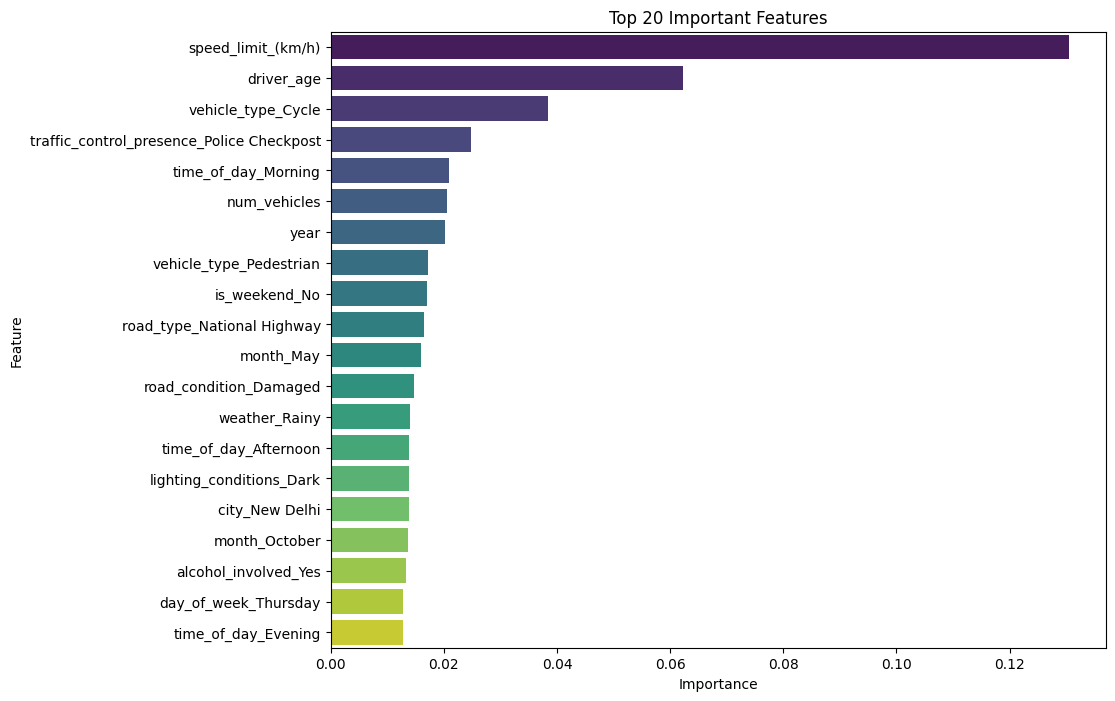

In [6]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=importance.head(20),
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Top 20 Important Features")

plt.show()

In [7]:
importance.to_csv(
    "../models/feature_importance.csv",
    index=False
)

print("Feature Importance Saved!")

Feature Importance Saved!


In [8]:
df = joblib.load("../data/processed/final_dataframe.pkl")

print(df.shape)

df.head()

(3000, 30)


,state,city,year,month,day_of_week,time,severity,num_vehicles,vehicle_type,number_of_casualties,...,alcohol_involved,accident_location_details,accident_hour,time_of_day,driver_age_group,is_multi_vehicle,is_weekend,is_night,is_peak_hour,target_severity
0,Jammu and Kashmir,Unknown,2021,May,Monday,1:46,Serious,5,Cycle,0,...,Yes,Curve,1,Late Night,Senior,Yes,No,Yes,No,1
1,Uttar Pradesh,Lucknow,2018,January,Wednesday,21:30,Minor,5,Truck,5,...,Yes,Straight Road,21,Evening,Adult,Yes,No,Yes,No,0
2,Chhattisgarh,Unknown,2023,May,Wednesday,5:37,Minor,5,Pedestrian,6,...,No,Bridge,5,Morning,Adult,Yes,No,Yes,No,0
3,Uttar Pradesh,Lucknow,2020,June,Saturday,0:31,Minor,3,Bus,10,...,Yes,Straight Road,0,Late Night,Adult,Yes,Yes,Yes,No,0
4,Sikkim,Unknown,2021,August,Thursday,11:21,Minor,5,Cycle,7,...,No,Intersection,11,Morning,Adult,Yes,No,No,No,0


In [9]:
def generate_prediction_explanation(row, prediction):

    reasons = []

    if row["alcohol_involved"] == "Yes":
        reasons.append("alcohol involvement")

    if row["road_type"] == "National Highway":
        reasons.append("highway driving")

    if row["road_condition"] == "Wet":
        reasons.append("wet road")

    if row["lighting_conditions"] == "Dark":
        reasons.append("poor lighting")

    if row["speed_limit_(km/h)"] >= 80:
        reasons.append("high speed")

    if row["is_night"] == "Yes":
        reasons.append("night driving")

    if len(reasons) == 0:
        explanation = (
            "The model predicted this accident severity because no major "
            "high-risk factors were detected in the available features."
        )
    else:
        explanation = (
            f"The model predicted '{prediction}' because the accident involved "
            + ", ".join(reasons[:-1])
            + (" and " if len(reasons) > 1 else "")
            + reasons[-1]
            + ". These were among the strongest contributing risk factors."
        )

    return explanation

In [10]:
reverse_map = {
    0: "Minor",
    1: "Serious",
    2: "Fatal"
}

print("MODEL PREDICTIONS")

for i in range(5):

    sample = df.iloc[[i]]      # Keep as DataFrame

    sample_features = sample.drop(
        columns=["severity", "target_severity"],
        errors="ignore"
    )

    sample_processed = preprocessor.transform(sample_features)

    sample_processed = preprocessor.transform(sample_features)

    # Predict class
    prediction_encoded = model.predict(sample_processed)[0]
    
    # Predict probabilities
    probabilities = model.predict_proba(sample_processed)[0]


    print("\nPrediction Confidence")
    for cls, prob in zip(model.classes_, probabilities):
        print(f"{reverse_map[cls]} : {prob*100:.2f}%")

    prediction = reverse_map[prediction_encoded]

    actual = sample.iloc[0]["severity"]     

    print(f"\nSample {i+1}")

    print("Actual Severity    :", actual)
    print("Predicted Severity :", prediction)

    # <-- ADD THIS HERE
    if actual == prediction:
        print("Prediction Status : Correct")
    else:
        print("Prediction Status : Incorrect")

    # Explanation
    print(generate_prediction_explanation(
        sample.iloc[0],
        prediction
    ))

MODEL PREDICTIONS

Prediction Confidence
Minor : 37.21%
Serious : 36.05%
Fatal : 26.74%

Sample 1
Actual Severity    : Serious
Predicted Severity : Minor
Prediction Status : Incorrect
The model predicted 'Minor' because the accident involved alcohol involvement, highway driving, wet road, poor lighting and night driving. These were among the strongest contributing risk factors.

Prediction Confidence
Minor : 37.21%
Serious : 36.05%
Fatal : 26.74%

Sample 2
Actual Severity    : Minor
Predicted Severity : Minor
Prediction Status : Correct
The model predicted 'Minor' because the accident involved alcohol involvement, high speed and night driving. These were among the strongest contributing risk factors.

Prediction Confidence
Minor : 0.00%
Serious : 100.00%
Fatal : 0.00%

Sample 3
Actual Severity    : Minor
Predicted Severity : Serious
Prediction Status : Incorrect
The model predicted 'Serious' because the accident involved highway driving, high speed and night driving. These were among t

In [11]:
display(importance.head(20))

,Feature,Importance
2,speed_limit_(km/h),0.130455
3,driver_age,0.062276
86,vehicle_type_Cycle,0.038420
107,traffic_control_presence_Police Checkpost,0.024784
125,time_of_day_Morning,0.020832
1,num_vehicles,0.020639
0,year,0.020257
87,vehicle_type_Pedestrian,0.017190
131,is_weekend_No,0.017053
95,road_type_National Highway,0.016415


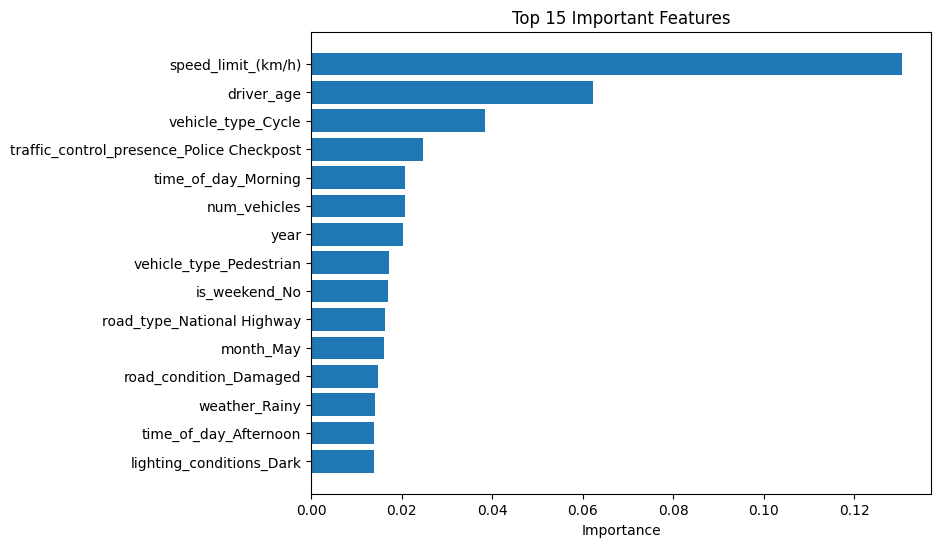

In [12]:
top = importance.head(15)

plt.figure(figsize=(8,6))
plt.barh(top["Feature"], top["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 15 Important Features")
plt.xlabel("Importance")
plt.show()

In [13]:
print("PROJECT EVALUATION COMPLETED")

print(f"Final Model        : {type(model).__name__}")
print(f"Features Used      : {len(feature_names)}")
print(f"Top Feature        : {importance.iloc[0]['Feature']}")
print(f"Top Importance     : {importance.iloc[0]['Importance']:.4f}")

print("\nEvaluation completed successfully.")

PROJECT EVALUATION COMPLETED
Final Model        : DecisionTreeClassifier
Features Used      : 137
Top Feature        : speed_limit_(km/h)
Top Importance     : 0.1305

Evaluation completed successfully.


In [14]:
from sklearn.pipeline import Pipeline

# Create Production Pipeline
production_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", model)
    ]
)

# Create backend artifact folder
os.makedirs("../backend/ml_artifacts", exist_ok=True)

# Save Production Pipeline
joblib.dump(
    production_pipeline,
    "../backend/ml_artifacts/severity_model.joblib"
)

print("Production Pipeline Saved Successfully!")

Production Pipeline Saved Successfully!


## Limitations

- The dataset contains limited predictive information.
- Many features show weak relationships with the target.
- Additional variables such as traffic density, vehicle speed, and driver behavior could improve performance.